# Análisis exploratorio de datos

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [51]:
# Rutas
BASE = Path("datos_dengue_historicos")
DATA_DIR = BASE / "csv_unificado"
FIG_DIR = BASE / "figuras_eda"

FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "dengue_2020_2026.csv"

In [52]:
df = pd.read_csv(
    "datos_dengue_historicos/csv_unificado/dengue_2020_2026.csv",
    parse_dates=["FECHA"]
)

df = df.set_index("FECHA")

df

,SEXO,EDAD,REGION,GRUPO_EDAD,ESTADO,MUNICIPIO,LAT,LON
FECHA,,,,,,,,
2020-01-01,M,36,Region 1,30 a 39 anios,SINALOA,CULIACAN,24.662580,-107.259452
2020-01-01,M,25,Region 5,18 a 29 anios,OAXACA,SANTO DOMINGO DE MORELOS,15.833547,-96.634413
2020-01-01,H,22,Region 5,18 a 29 anios,OAXACA,SAN ANTONIO NANAHUATIPAM,18.146151,-97.164512
2020-01-01,M,14,Region 6,<18,YUCATAN,AKIL,20.262062,-89.348379
2020-01-01,H,77,Region 6,>=60 anios,YUCATAN,CELESTUN,20.888217,-90.278038
...,...,...,...,...,...,...,...,...
2026-05-18,H,8,Region 1,<18,BAJA CALIFORNIA SUR,LA PAZ,24.184341,-110.641288
2026-05-19,H,58,Region 4,50 a 59 anios,JALISCO,COCULA,20.390353,-103.824459
2026-05-19,M,21,Region 4,18 a 29 anios,JALISCO,COCULA,20.390353,-103.824459


In [53]:
# Revisión inicial

print("Dimensiones del dataset:")
print(df.shape)

print("\nRango temporal:")
print(df.index.min(), "a", df.index.max())

print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isna().sum())

print("\nCasos por año:")
print(df.groupby(df.index.year).size())



Dimensiones del dataset:
(242999, 8)

Rango temporal:
2020-01-01 00:00:00 a 2026-05-20 00:00:00

Columnas:
['SEXO', 'EDAD', 'REGION', 'GRUPO_EDAD', 'ESTADO', 'MUNICIPIO', 'LAT', 'LON']

Tipos de datos:
SEXO           object
EDAD            int64
REGION         object
GRUPO_EDAD     object
ESTADO         object
MUNICIPIO      object
LAT           float64
LON           float64
dtype: object

Valores faltantes:
SEXO          0
EDAD          0
REGION        0
GRUPO_EDAD    0
ESTADO        0
MUNICIPIO     0
LAT           0
LON           0
dtype: int64

Casos por año:
FECHA
2020     24224
2021      6326
2022     12122
2023     53319
2024    123140
2025     21732
2026      2136
dtype: int64


In [54]:
# Casos confirmados por año
casos_anuales = df.groupby(df.index.year).size()
casos_anuales.index.name = "ANIO"

casos_anuales_df = casos_anuales.reset_index(name="CASOS_CONFIRMADOS")

casos_anuales_df["PORCENTAJE"] = (
    100 * casos_anuales_df["CASOS_CONFIRMADOS"] 
    / casos_anuales_df["CASOS_CONFIRMADOS"].sum()
)

print("Casos confirmados anuales:")
casos_anuales_df

Casos confirmados anuales:


,ANIO,CASOS_CONFIRMADOS,PORCENTAJE
0,2020,24224,9.968765
1,2021,6326,2.603303
2,2022,12122,4.988498
3,2023,53319,21.942066
4,2024,123140,50.675106
5,2025,21732,8.943247
6,2026,2136,0.879016


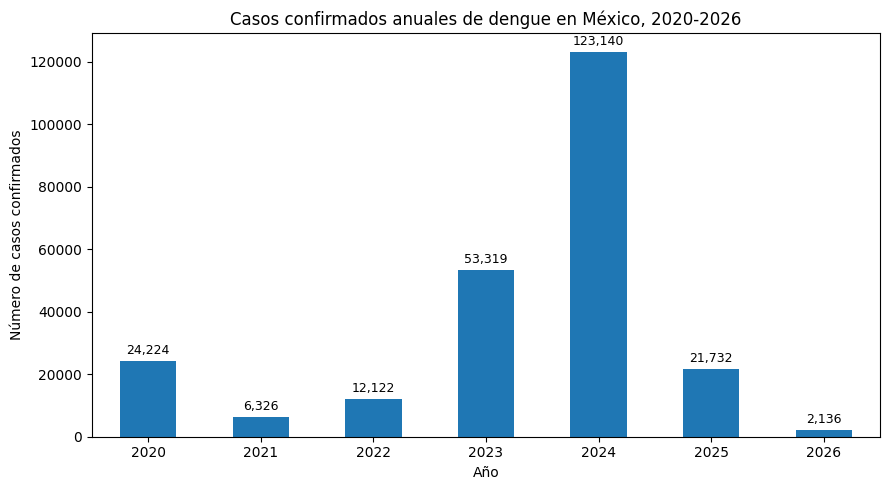

In [55]:
fig, ax = plt.subplots(figsize=(9, 5))

casos_anuales.plot(kind="bar", ax=ax)

ax.set_title("Casos confirmados anuales de dengue en México, 2020-2026")
ax.set_xlabel("Año")
ax.set_ylabel("Número de casos confirmados")
ax.tick_params(axis="x", rotation=0)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(v):,}" for v in casos_anuales.values],
        fontsize=9,
        padding=3
    )

fig.tight_layout()

fig_path = FIG_DIR / "fig_01_casos_confirmados_anuales_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [56]:
# Casos confirmados por mes
casos_mensuales = df.resample("MS").size()
casos_mensuales.name = "CASOS_CONFIRMADOS"

casos_mensuales_df = casos_mensuales.reset_index()
casos_mensuales_df["ANIO"] = casos_mensuales_df["FECHA"].dt.year
casos_mensuales_df["MES"] = casos_mensuales_df["FECHA"].dt.month

print("Primeros meses:")
print(casos_mensuales_df.head())

print("\nÚltimos meses:")
print(casos_mensuales_df.tail())

print("\nMeses con más casos confirmados:")
print(
    casos_mensuales_df
    .sort_values("CASOS_CONFIRMADOS", ascending=False)
    .head(15)
)


Primeros meses:
       FECHA  CASOS_CONFIRMADOS  ANIO  MES
0 2020-01-01               1140  2020    1
1 2020-02-01                864  2020    2
2 2020-03-01                567  2020    3
3 2020-04-01                477  2020    4
4 2020-05-01                914  2020    5

Últimos meses:
        FECHA  CASOS_CONFIRMADOS  ANIO  MES
72 2026-01-01                719  2026    1
73 2026-02-01                351  2026    2
74 2026-03-01                396  2026    3
75 2026-04-01                406  2026    4
76 2026-05-01                264  2026    5

Meses con más casos confirmados:
        FECHA  CASOS_CONFIRMADOS  ANIO  MES
56 2024-09-01              25771  2024    9
57 2024-10-01              24452  2024   10
55 2024-08-01              21599  2024    8
58 2024-11-01              16505  2024   11
44 2023-09-01              14145  2023    9
45 2023-10-01              12187  2023   10
54 2024-07-01              10663  2024    7
43 2023-08-01               8805  2023    8
53 2024-06-01   

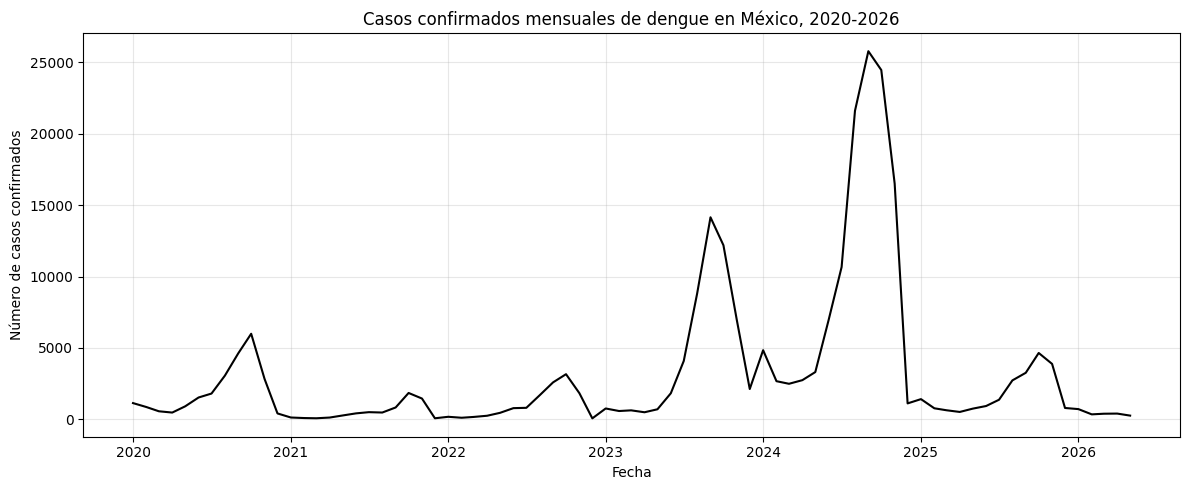

In [65]:
fig, ax = plt.subplots(figsize=(12, 5))


ax.plot(casos_mensuales, color = 'black')
ax.set_title("Casos confirmados mensuales de dengue en México, 2020-2026")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de casos confirmados")

ax.grid(True, alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_02_casos_confirmados_mensuales_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [66]:
# Estacionalidad mensual por año

# Tabla año-mes
tabla_mensual = (
    casos_mensuales_df
    .pivot(index="MES", columns="ANIO", values="CASOS_CONFIRMADOS")
)


meses = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

tabla_mensual.index = tabla_mensual.index.map(meses)

print("Casos confirmados por mes y año:")
tabla_mensual


Casos confirmados por mes y año:


ANIO,2020,2021,2022,2023,2024,2025,2026
MES,,,,,,,
Ene,1140.0,131.0,181.0,763.0,4842.0,1418.0,719.0
Feb,864.0,93.0,114.0,585.0,2673.0,776.0,351.0
Mar,567.0,78.0,171.0,632.0,2491.0,639.0,396.0
Abr,477.0,128.0,254.0,498.0,2745.0,520.0,406.0
May,914.0,273.0,458.0,707.0,3312.0,751.0,264.0
Jun,1531.0,420.0,786.0,1828.0,6969.0,935.0,NaN
Jul,1808.0,505.0,809.0,4089.0,10663.0,1374.0,NaN
Ago,3060.0,479.0,1691.0,8805.0,21599.0,2729.0,NaN
Sep,4621.0,834.0,2591.0,14145.0,25771.0,3261.0,NaN


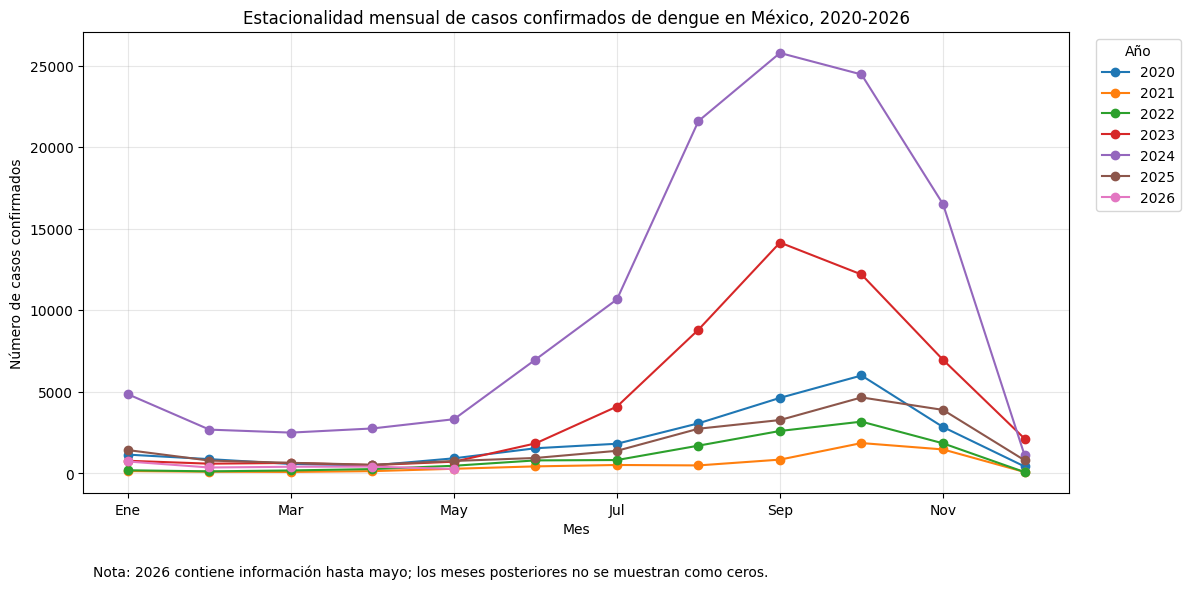

In [67]:
fig, ax = plt.subplots(figsize=(12, 6))

tabla_mensual.plot(marker="o", ax=ax)

ax.set_title("Estacionalidad mensual de casos confirmados de dengue en México, 2020-2026")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de casos confirmados")
ax.grid(True, alpha=0.3)

ax.legend(
    title="Año",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


ax.text(
    0.01,
    -0.18,
    "Nota: 2026 contiene información hasta mayo; los meses posteriores no se muestran como ceros.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "fig_03_estacionalidad_mensual_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [68]:
# Casos confirmados por estado
casos_estado = (
    df
    .groupby("ESTADO")
    .size()
    .sort_values(ascending=False)
)

casos_estado_df = casos_estado.reset_index(name="CASOS_CONFIRMADOS")

casos_estado_df["PORCENTAJE"] = (
    100 * casos_estado_df["CASOS_CONFIRMADOS"] 
    / casos_estado_df["CASOS_CONFIRMADOS"].sum()
)

print("Casos confirmados por estado:")
display(casos_estado_df)

print("\nTop 15 estados con más casos confirmados:")
display(casos_estado_df.head(15))


Casos confirmados por estado:


,ESTADO,CASOS_CONFIRMADOS,PORCENTAJE
0,JALISCO,29352,12.079062
1,VERACRUZ,25335,10.425969
2,NUEVO LEON,13184,5.425537
3,GUERRERO,12435,5.117305
4,MORELOS,12426,5.113601
5,MICHOACAN,11625,4.783970
6,YUCATAN,11514,4.738291
7,SINALOA,10026,4.125943
8,CHIAPAS,9970,4.102898
9,PUEBLA,9695,3.989728



Top 15 estados con más casos confirmados:


,ESTADO,CASOS_CONFIRMADOS,PORCENTAJE
0,JALISCO,29352,12.079062
1,VERACRUZ,25335,10.425969
2,NUEVO LEON,13184,5.425537
3,GUERRERO,12435,5.117305
4,MORELOS,12426,5.113601
5,MICHOACAN,11625,4.783970
6,YUCATAN,11514,4.738291
7,SINALOA,10026,4.125943
8,CHIAPAS,9970,4.102898
9,PUEBLA,9695,3.989728


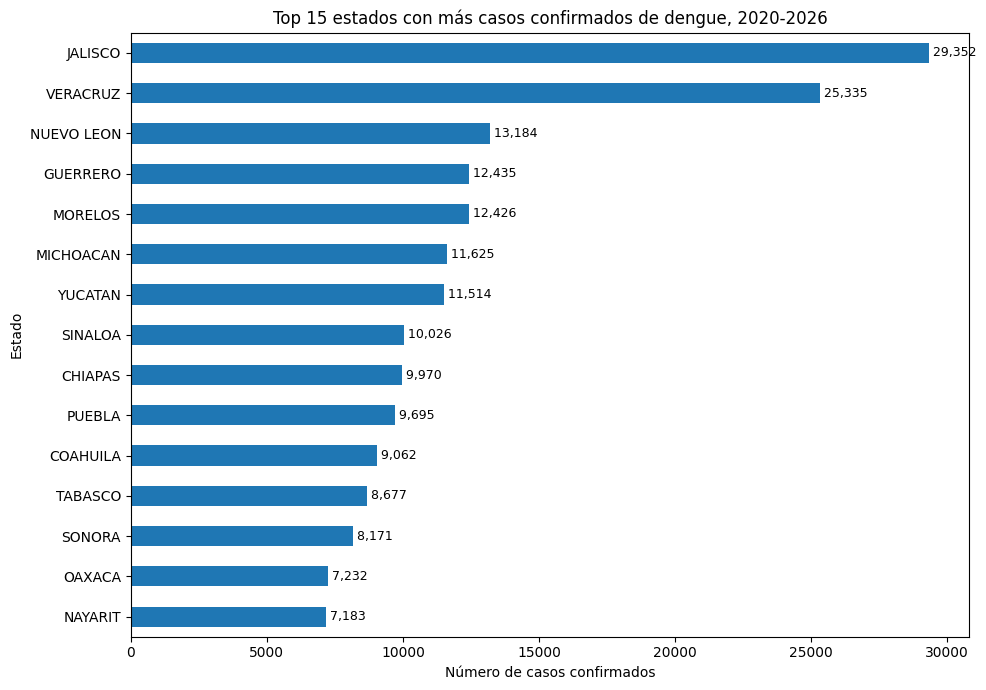

In [69]:
top_estados = casos_estado.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

top_estados.plot(kind="barh", ax=ax)

ax.set_title("Top 15 estados con más casos confirmados de dengue, 2020-2026")
ax.set_xlabel("Número de casos confirmados")
ax.set_ylabel("Estado")


for i, value in enumerate(top_estados.values):
    ax.text(
        value,
        i,
        f" {int(value):,}",
        va="center",
        fontsize=9
    )

fig.tight_layout()

fig_path = FIG_DIR / "fig_04_top15_estados_casos_confirmados_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


In [70]:
# Casos confirmados por región

casos_region = (
    df
    .groupby("REGION")
    .size()
    .sort_values(ascending=False)
)

casos_region_df = casos_region.reset_index(name="CASOS_CONFIRMADOS")

casos_region_df["PORCENTAJE"] = (
    100 * casos_region_df["CASOS_CONFIRMADOS"] 
    / casos_region_df["CASOS_CONFIRMADOS"].sum()
)

print("Casos confirmados por región:")
display(casos_region_df)

# Casos por región y año
casos_region_anio = (
    df
    .groupby([df.index.year, "REGION"])
    .size()
    .unstack(fill_value=0)
)

casos_region_anio.index.name = "ANIO"

print("\nCasos confirmados por año y región:")
display(casos_region_anio)




Casos confirmados por región:


,REGION,CASOS_CONFIRMADOS,PORCENTAJE
0,Region 5,54972,22.622315
1,Region 4,54518,22.435483
2,Region 3,34071,14.021045
3,Region 6,29940,12.321038
4,Region 7,27359,11.258894
5,Region 1,22716,9.348187
6,Region 8,17466,7.187684
7,Region 2,1957,0.805353



Casos confirmados por año y región:


REGION,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8
ANIO,,,,,,,,
2020,768,147,7391,9067,2654,807,1864,1526
2021,1522,6,1248,581,1929,114,877,49
2022,3015,66,655,396,3965,1959,2055,11
2023,1055,28,1109,2836,18909,19794,7652,1936
2024,8285,1687,21558,37347,22847,5497,14055,11864
2025,7014,20,2063,4134,4291,1302,840,2068
2026,1057,3,47,157,377,467,16,12


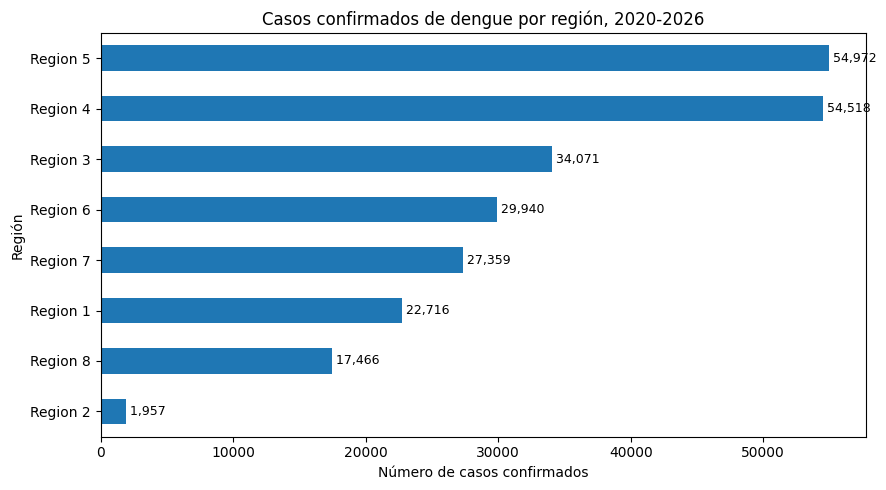

In [71]:
fig, ax = plt.subplots(figsize=(9, 5))

casos_region.sort_values(ascending=True).plot(kind="barh", ax=ax)

ax.set_title("Casos confirmados de dengue por región, 2020-2026")
ax.set_xlabel("Número de casos confirmados")
ax.set_ylabel("Región")

for i, value in enumerate(casos_region.sort_values(ascending=True).values):
    ax.text(
        value,
        i,
        f" {int(value):,}",
        va="center",
        fontsize=9
    )

fig.tight_layout()

fig_path = FIG_DIR / "fig_05_casos_confirmados_por_region_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [72]:
# Distribución regional por año

orden_regiones = [
    "Region 1", "Region 2", "Region 3", "Region 4",
    "Region 5", "Region 6", "Region 7", "Region 8"
]

casos_region_anio = casos_region_anio[orden_regiones]

# Porcentaje dentro de cada año
casos_region_anio_pct = casos_region_anio.div(
    casos_region_anio.sum(axis=1),
    axis=0
) * 100

print("Casos confirmados por año y región:")
display(casos_region_anio)

print("\nPorcentaje dentro de cada año:")
display(casos_region_anio_pct.round(2))



Casos confirmados por año y región:


REGION,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8
ANIO,,,,,,,,
2020,768,147,7391,9067,2654,807,1864,1526
2021,1522,6,1248,581,1929,114,877,49
2022,3015,66,655,396,3965,1959,2055,11
2023,1055,28,1109,2836,18909,19794,7652,1936
2024,8285,1687,21558,37347,22847,5497,14055,11864
2025,7014,20,2063,4134,4291,1302,840,2068
2026,1057,3,47,157,377,467,16,12



Porcentaje dentro de cada año:


REGION,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8
ANIO,,,,,,,,
2020,3.17,0.61,30.51,37.43,10.96,3.33,7.69,6.30
2021,24.06,0.09,19.73,9.18,30.49,1.80,13.86,0.77
2022,24.87,0.54,5.40,3.27,32.71,16.16,16.95,0.09
2023,1.98,0.05,2.08,5.32,35.46,37.12,14.35,3.63
2024,6.73,1.37,17.51,30.33,18.55,4.46,11.41,9.63
2025,32.27,0.09,9.49,19.02,19.75,5.99,3.87,9.52
2026,49.49,0.14,2.20,7.35,17.65,21.86,0.75,0.56


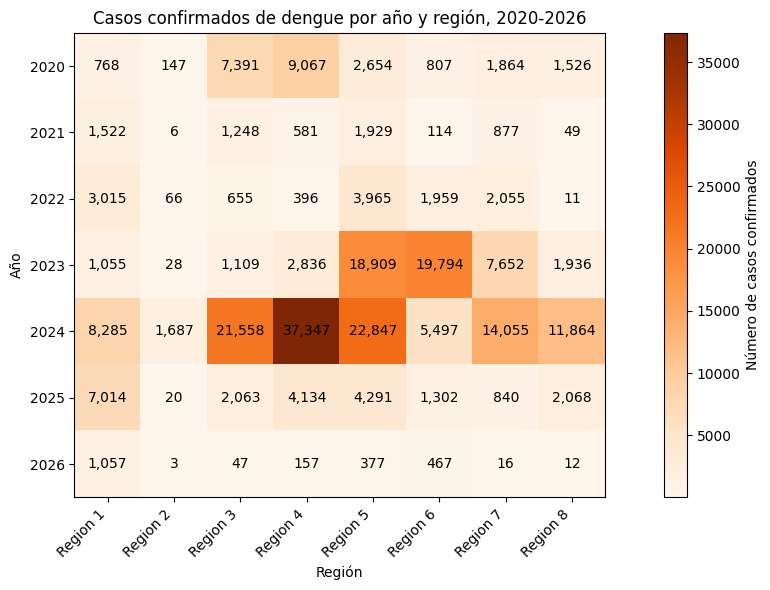

In [76]:
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(casos_region_anio.values, cmap='Oranges')

ax.set_title("Casos confirmados de dengue por año y región, 2020-2026")
ax.set_xlabel("Región")
ax.set_ylabel("Año")

ax.set_xticks(range(len(casos_region_anio.columns)))
ax.set_xticklabels(casos_region_anio.columns, rotation=45, ha="right")

ax.set_yticks(range(len(casos_region_anio.index)))
ax.set_yticklabels(casos_region_anio.index)

# Anotar valores
for i in range(casos_region_anio.shape[0]):
    for j in range(casos_region_anio.shape[1]):
        valor = casos_region_anio.iloc[i, j]
        ax.text(
            j,
            i,
            f"{int(valor):,}",
            ha="center",
            va="center",
            fontsize=10
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Número de casos confirmados")

fig.tight_layout()

fig_path = FIG_DIR / "fig_06_casos_confirmados_region_anio_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


In [77]:
# Distribución de casos confirmados por sexo

# M = Mujer
# H = Hombre

casos_sexo = df["SEXO"].value_counts()

orden_sexo = ["M", "H"]
casos_sexo = casos_sexo.reindex(orden_sexo)

casos_sexo_df = casos_sexo.reset_index()
casos_sexo_df.columns = ["SEXO", "CASOS_CONFIRMADOS"]

casos_sexo_df["SEXO_LABEL"] = casos_sexo_df["SEXO"].map({
    "M": "Mujer",
    "H": "Hombre"
})

casos_sexo_df["PORCENTAJE"] = (
    100 * casos_sexo_df["CASOS_CONFIRMADOS"]
    / casos_sexo_df["CASOS_CONFIRMADOS"].sum()
)

print("Casos confirmados por sexo:")
casos_sexo_df

Casos confirmados por sexo:


,SEXO,CASOS_CONFIRMADOS,SEXO_LABEL,PORCENTAJE
0,M,134223,Mujer,55.23603
1,H,108776,Hombre,44.76397


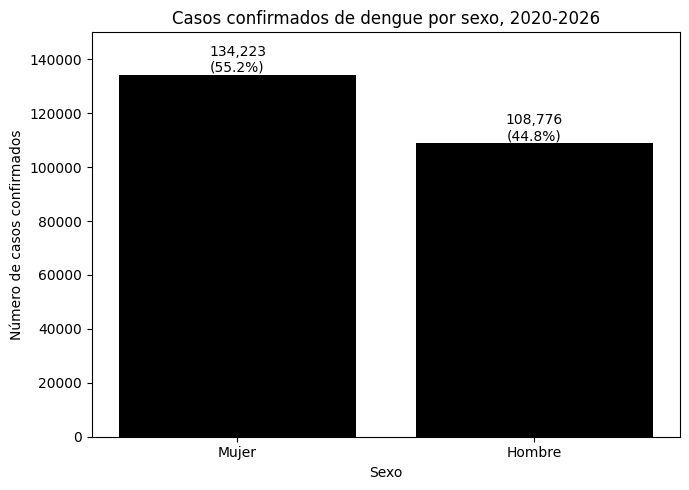

In [78]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    casos_sexo_df["SEXO_LABEL"],
    casos_sexo_df["CASOS_CONFIRMADOS"], color = 'black'
)

ax.set_title("Casos confirmados de dengue por sexo, 2020-2026")
ax.set_xlabel("Sexo")
ax.set_ylabel("Número de casos confirmados")
ax.set_ylim(0, 150_000)

for i, row in casos_sexo_df.iterrows():
    ax.text(
        i,
        row["CASOS_CONFIRMADOS"],
        f"{int(row['CASOS_CONFIRMADOS']):,}\n({row['PORCENTAJE']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.tight_layout()

fig_path = FIG_DIR / "fig_07_casos_confirmados_por_sexo_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


In [79]:
# Celda 9. Distribución de casos confirmados por grupo de edad

orden_grupo_edad = [
    "<18",
    "18 a 29 anios",
    "30 a 39 anios",
    "40 a 49 anios",
    "50 a 59 anios",
    ">=60 anios"
]

casos_grupo_edad = (
    df["GRUPO_EDAD"]
    .value_counts()
    .reindex(orden_grupo_edad)
)

casos_grupo_edad_df = casos_grupo_edad.reset_index()
casos_grupo_edad_df.columns = ["GRUPO_EDAD", "CASOS_CONFIRMADOS"]

casos_grupo_edad_df["PORCENTAJE"] = (
    100 * casos_grupo_edad_df["CASOS_CONFIRMADOS"]
    / casos_grupo_edad_df["CASOS_CONFIRMADOS"].sum()
)

print("Casos confirmados por grupo de edad:")
casos_grupo_edad_df


Casos confirmados por grupo de edad:


,GRUPO_EDAD,CASOS_CONFIRMADOS,PORCENTAJE
0,<18,83608,34.406726
1,18 a 29 anios,60259,24.798044
2,30 a 39 anios,37355,15.372491
3,40 a 49 anios,26691,10.983996
4,50 a 59 anios,18981,7.811143
5,>=60 anios,16105,6.627599


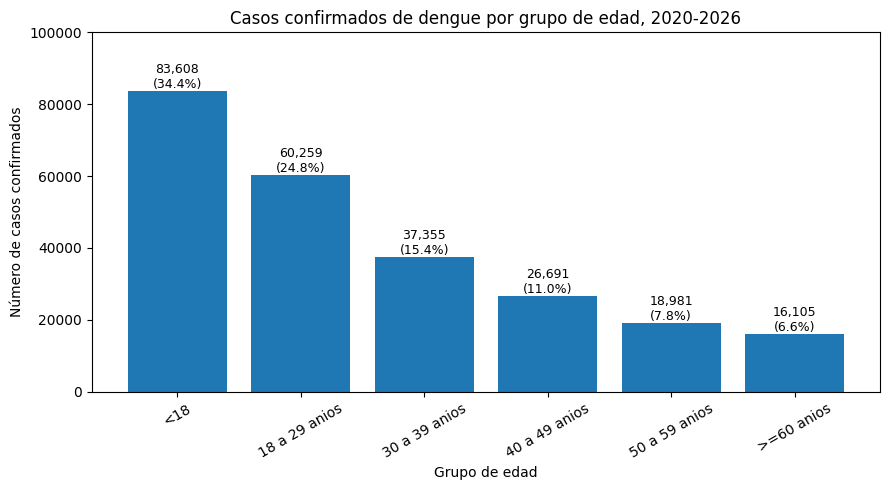

In [80]:
# casos confirmados por grupo de edad

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    casos_grupo_edad_df["GRUPO_EDAD"],
    casos_grupo_edad_df["CASOS_CONFIRMADOS"]
)

ax.set_title("Casos confirmados de dengue por grupo de edad, 2020-2026")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("Número de casos confirmados")
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, 100_000)

for i, row in casos_grupo_edad_df.iterrows():
    ax.text(
        i,
        row["CASOS_CONFIRMADOS"],
        f"{int(row['CASOS_CONFIRMADOS']):,}\n({row['PORCENTAJE']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

fig.tight_layout()

fig_path = FIG_DIR / "fig_08_casos_confirmados_por_grupo_edad_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


In [81]:
# Casos confirmados por grupo de edad y sexo

grupo_edad_sexo = (
    df
    .groupby(["GRUPO_EDAD", "SEXO"])
    .size()
    .unstack(fill_value=0)
    .reindex(orden_grupo_edad)
)


grupo_edad_sexo = grupo_edad_sexo[["M", "H"]]


grupo_edad_sexo_pct = grupo_edad_sexo.div(
    grupo_edad_sexo.sum(axis=1),
    axis=0
) * 100

print("Casos confirmados por grupo de edad y sexo:")
display(grupo_edad_sexo)

print("\nPorcentaje por sexo dentro de cada grupo de edad:")
display(grupo_edad_sexo_pct.round(2))


Casos confirmados por grupo de edad y sexo:


SEXO,M,H
GRUPO_EDAD,,
<18,40152,43456
18 a 29 anios,35369,24890
30 a 39 anios,22718,14637
40 a 49 anios,15713,10978
50 a 59 anios,11267,7714
>=60 anios,9004,7101



Porcentaje por sexo dentro de cada grupo de edad:


SEXO,M,H
GRUPO_EDAD,,
<18,48.02,51.98
18 a 29 anios,58.69,41.31
30 a 39 anios,60.82,39.18
40 a 49 anios,58.87,41.13
50 a 59 anios,59.36,40.64
>=60 anios,55.91,44.09


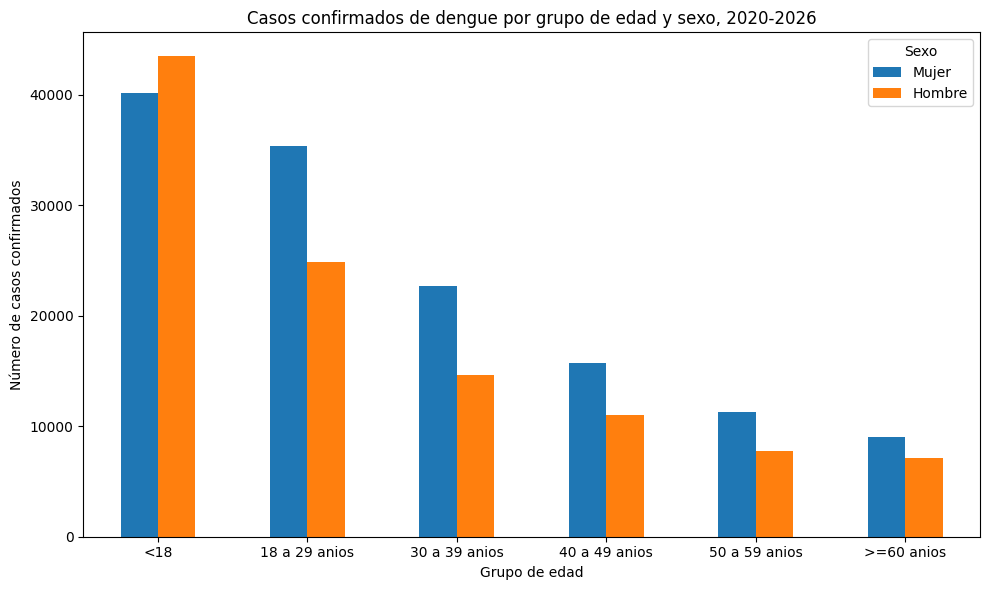

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))

grupo_edad_sexo.plot(kind="bar", ax=ax)

ax.set_title("Casos confirmados de dengue por grupo de edad y sexo, 2020-2026")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("Número de casos confirmados")
ax.tick_params(axis="x", rotation=0)

ax.legend(
    title="Sexo",
    labels=["Mujer", "Hombre"]
)

fig.tight_layout()

fig_path = FIG_DIR / "fig_09_casos_confirmados_grupo_edad_sexo_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


In [83]:
# Distribución de edad de los casos confirmados

print("Resumen de edad:")
display(df["EDAD"].describe())

print("\nEdades más frecuentes:")
display(df["EDAD"].value_counts().sort_index().head(20))


Resumen de edad:


count    242999.000000
mean         28.486232
std          17.818479
min           0.000000
25%          14.000000
50%          25.000000
75%          40.000000
max         112.000000
Name: EDAD, dtype: float64


Edades más frecuentes:


EDAD
0     1596
1      834
2     1038
3     1286
4     1851
5     2647
6     3417
7     4063
8     4962
9     5620
10    6317
11    6874
12    7551
13    7682
14    7549
15    7414
16    6647
17    6260
18    5382
19    5337
Name: count, dtype: int64

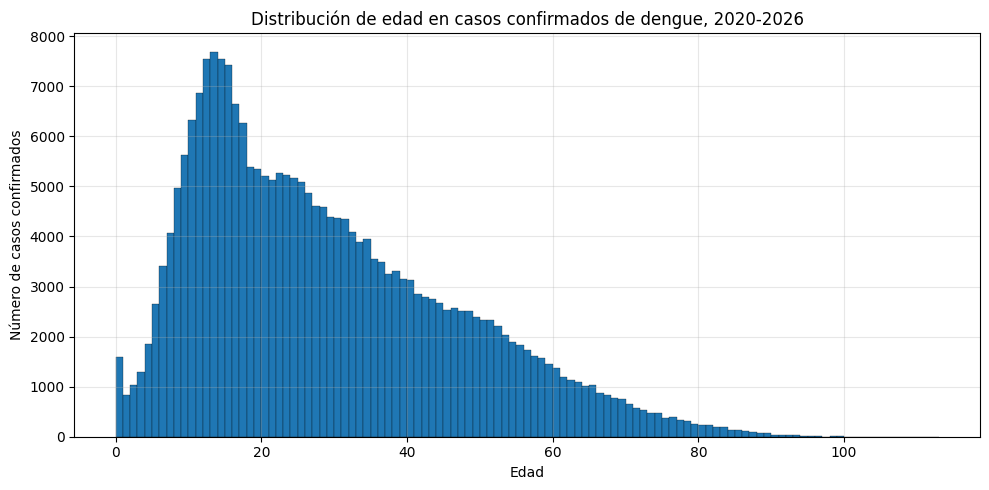

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["EDAD"],
    bins=range(0, int(df["EDAD"].max()) + 2),
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Distribución de edad en casos confirmados de dengue, 2020-2026")
ax.set_xlabel("Edad")
ax.set_ylabel("Número de casos confirmados")

ax.grid(True, alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_10_distribucion_edad_casos_confirmados_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


In [85]:
# Distribución de edad por sexo

edad_mujer = df.loc[df["SEXO"] == "M", "EDAD"]
edad_hombre = df.loc[df["SEXO"] == "H", "EDAD"]

resumen_edad_sexo = (
    df
    .groupby("SEXO")["EDAD"]
    .describe()
    .rename(index={"M": "Mujer", "H": "Hombre"})
)

print("Resumen de edad por sexo:")
resumen_edad_sexo

Resumen de edad por sexo:


,count,mean,std,min,25%,50%,75%,max
SEXO,,,,,,,,
Hombre,108776.0,27.134589,18.064421,0.0,13.0,22.0,38.0,112.0
Mujer,134223.0,29.581622,17.540471,0.0,16.0,26.0,41.0,108.0


/var/folders/16/rwkptmp92_b7tw7nx11rkvbw0000gn/T/ipykernel_3768/1336301806.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


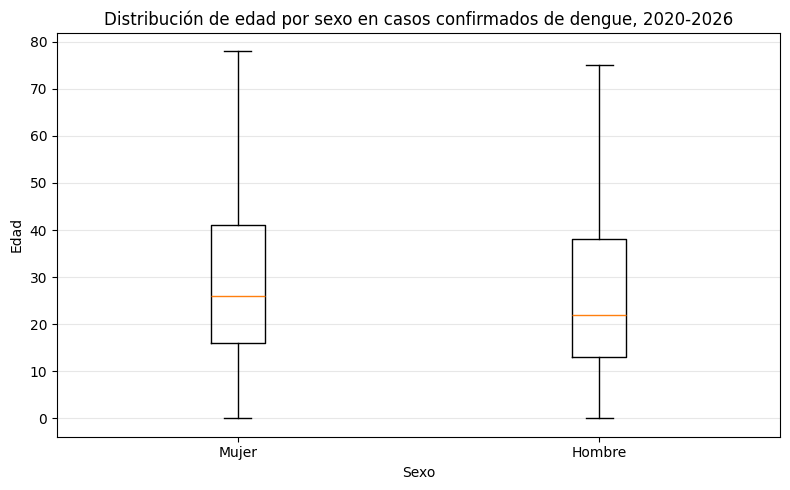

In [86]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [edad_mujer, edad_hombre],
    labels=["Mujer", "Hombre"],
    showfliers=False
)

ax.set_title("Distribución de edad por sexo en casos confirmados de dengue, 2020-2026")
ax.set_xlabel("Sexo")
ax.set_ylabel("Edad")

ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_11_distribucion_edad_por_sexo_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [87]:
# Municipios con más casos confirmados de dengue

casos_municipio = (
    df
    .groupby(["ESTADO", "MUNICIPIO"])
    .size()
    .sort_values(ascending=False)
)

casos_municipio_df = casos_municipio.reset_index(name="CASOS_CONFIRMADOS")

casos_municipio_df["PORCENTAJE"] = (
    100 * casos_municipio_df["CASOS_CONFIRMADOS"]
    / casos_municipio_df["CASOS_CONFIRMADOS"].sum()
)

casos_municipio_df["ESTADO_MUNICIPIO"] = (
    casos_municipio_df["MUNICIPIO"] + ", " + casos_municipio_df["ESTADO"]
)

print("Top 20 municipios con más casos confirmados:")
casos_municipio_df.head(20)



Top 20 municipios con más casos confirmados:


,ESTADO,MUNICIPIO,CASOS_CONFIRMADOS,PORCENTAJE,ESTADO_MUNICIPIO
0,JALISCO,GUADALAJARA,7469,3.073675,"GUADALAJARA, JALISCO"
1,YUCATAN,MERIDA,5055,2.080255,"MERIDA, YUCATAN"
2,GUERRERO,ACAPULCO DE JUAREZ,4367,1.797127,"ACAPULCO DE JUAREZ, GUERRERO"
3,JALISCO,ZAPOPAN,4185,1.722229,"ZAPOPAN, JALISCO"
4,VERACRUZ,VERACRUZ,4152,1.708649,"VERACRUZ, VERACRUZ"
5,QUINTANA ROO,BENITO JUAREZ,3806,1.566262,"BENITO JUAREZ, QUINTANA ROO"
6,NUEVO LEON,MONTERREY,3690,1.518525,"MONTERREY, NUEVO LEON"
7,JALISCO,SAN PEDRO TLAQUEPAQUE,3615,1.487660,"SAN PEDRO TLAQUEPAQUE, JALISCO"
8,AGUASCALIENTES,AGUASCALIENTES,3494,1.437866,"AGUASCALIENTES, AGUASCALIENTES"
9,TABASCO,CENTRO,3347,1.377372,"CENTRO, TABASCO"


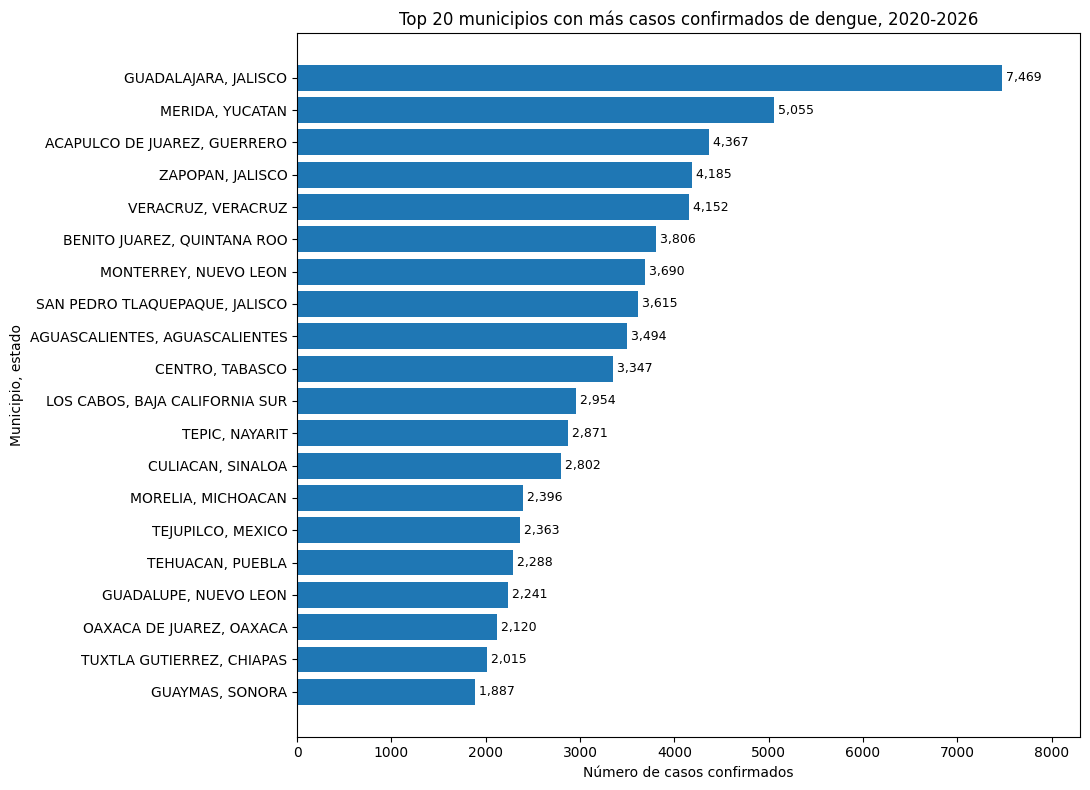

In [88]:
top_municipios = casos_municipio_df.head(20).copy()
top_municipios = top_municipios.sort_values("CASOS_CONFIRMADOS", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    top_municipios["ESTADO_MUNICIPIO"],
    top_municipios["CASOS_CONFIRMADOS"]
)

ax.set_title("Top 20 municipios con más casos confirmados de dengue, 2020-2026")
ax.set_xlabel("Número de casos confirmados")
ax.set_ylabel("Municipio, estado")
ax.set_xlim(0, 8_300)

for i, value in enumerate(top_municipios["CASOS_CONFIRMADOS"]):
    ax.text(
        value,
        i,
        f" {int(value):,}",
        va="center",
        fontsize=9
    )

fig.tight_layout()

fig_path = FIG_DIR / "fig_12_top20_municipios_casos_confirmados_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [89]:
# Mapa de burbujas municipal de casos confirmados

casos_municipio_geo = (
    df
    .groupby(["ESTADO", "MUNICIPIO", "LAT", "LON"])
    .size()
    .reset_index(name="CASOS_CONFIRMADOS")
    .sort_values("CASOS_CONFIRMADOS", ascending=False)
)

print("Municipios agregados:")
display(casos_municipio_geo.shape)

print("\nTop 15 municipios con coordenadas:")
display(casos_municipio_geo.head(15))

Municipios agregados:


(1746, 5)


Top 15 municipios con coordenadas:


,ESTADO,MUNICIPIO,LAT,LON,CASOS_CONFIRMADOS
453,JALISCO,GUADALAJARA,20.675971,-103.335807,7469
1663,YUCATAN,MERIDA,20.984072,-89.639526,5055
278,GUERRERO,ACAPULCO DE JUAREZ,16.957128,-99.714175,4367
528,JALISCO,ZAPOPAN,20.794896,-103.494184,4185
1603,VERACRUZ,VERACRUZ,19.185604,-96.222198,4152
1227,QUINTANA ROO,BENITO JUAREZ,21.012355,-87.046967,3806
792,NUEVO LEON,MONTERREY,25.644787,-100.311000,3690
490,JALISCO,SAN PEDRO TLAQUEPAQUE,20.590910,-103.348908,3615
0,AGUASCALIENTES,AGUASCALIENTES,21.811436,-102.295803,3494
1349,TABASCO,CENTRO,18.009013,-92.860323,3347


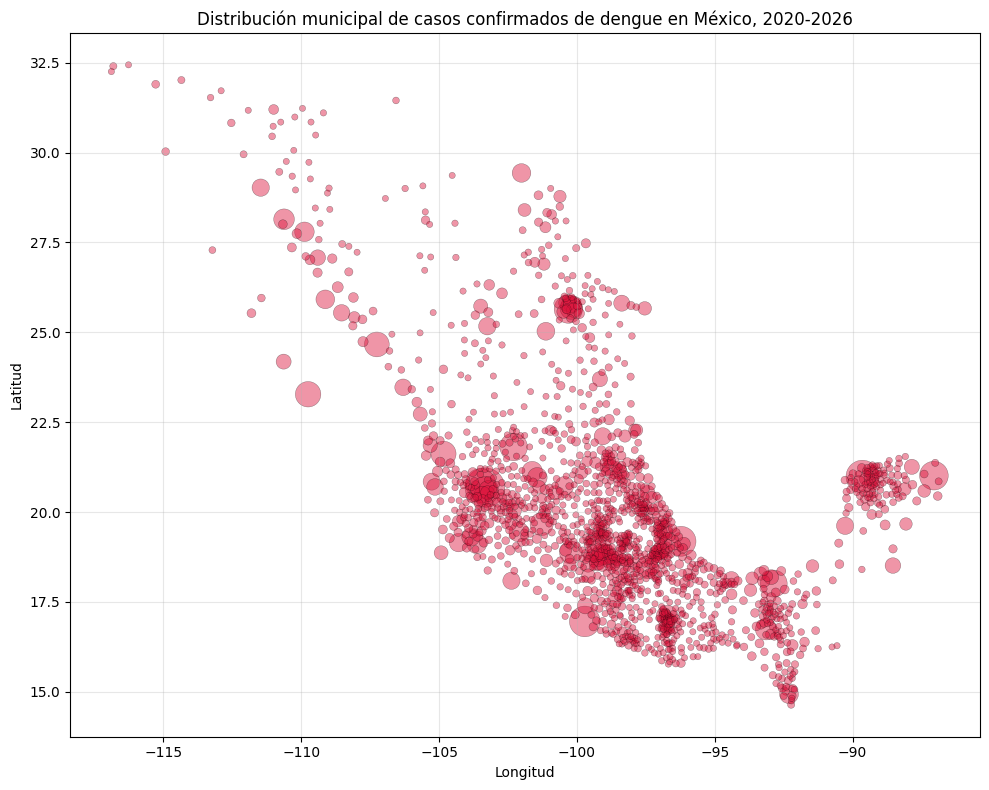

In [90]:
# mapa de burbujas municipal

fig, ax = plt.subplots(figsize=(10, 8))

# Escalamiento de burbujas
sizes = 20 + 800 * (
    casos_municipio_geo["CASOS_CONFIRMADOS"] 
    / casos_municipio_geo["CASOS_CONFIRMADOS"].max()
)

ax.scatter(
    casos_municipio_geo["LON"],
    casos_municipio_geo["LAT"],
    s=sizes,
    color='crimson',
    alpha=0.45,
    edgecolors="black",
    linewidths=0.3
)

ax.set_title("Distribución municipal de casos confirmados de dengue en México, 2020-2026")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

ax.grid(True, alpha=0.3)



fig.tight_layout()

fig_path = FIG_DIR / "fig_13_mapa_burbujas_municipal_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [91]:
# Evolución anual en los 10 estados con más casos

top10_estados = (
    df.groupby("ESTADO")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

casos_estado_anio = (
    df[df["ESTADO"].isin(top10_estados)]
    .groupby([df[df["ESTADO"].isin(top10_estados)].index.year, "ESTADO"])
    .size()
    .unstack(fill_value=0)
)


casos_estado_anio = casos_estado_anio[top10_estados]
casos_estado_anio.index.name = "ANIO"

print("Casos confirmados por año en los 10 estados con más casos acumulados:")
display(casos_estado_anio)



Casos confirmados por año en los 10 estados con más casos acumulados:


ESTADO,JALISCO,VERACRUZ,NUEVO LEON,GUERRERO,MORELOS,MICHOACAN,YUCATAN,SINALOA,CHIAPAS,PUEBLA
ANIO,,,,,,,,,,
2020,5364,1480,2283,588,618,2513,147,721,318,989
2021,181,961,79,318,568,208,2,1384,239,127
2022,73,1651,63,848,587,165,423,660,909,166
2023,960,10282,102,3598,4172,1023,10385,223,3195,3205
2024,20419,7888,10544,6589,6343,6395,351,4672,4477,4748
2025,2307,2783,108,481,136,1276,196,2008,770,452
2026,48,290,5,13,2,45,10,358,62,8


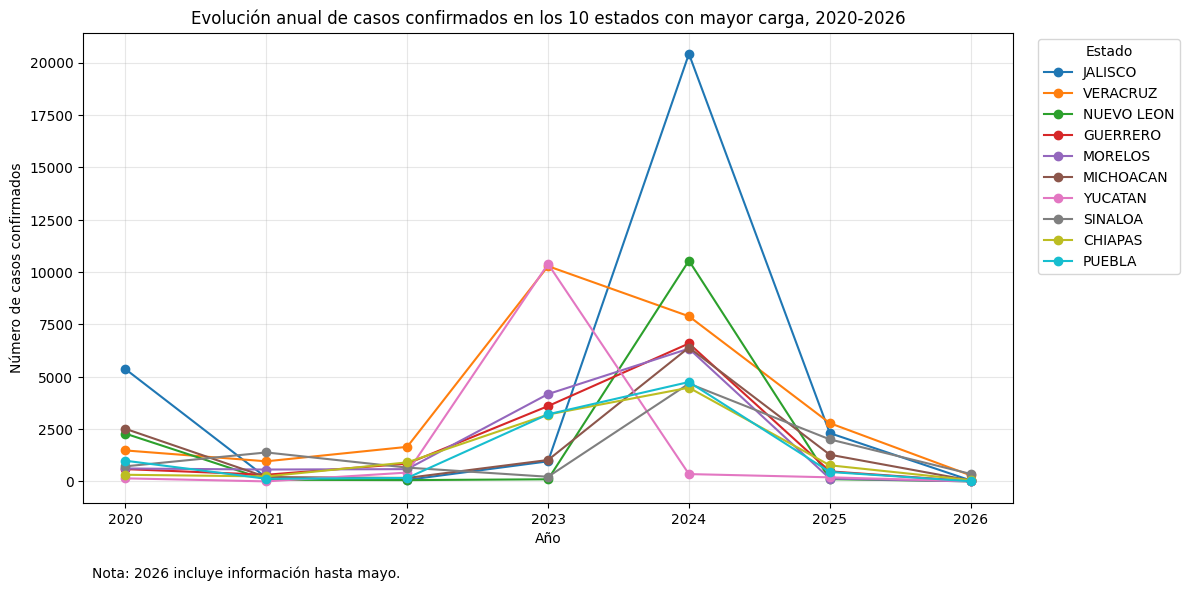

In [92]:
fig, ax = plt.subplots(figsize=(12, 6))

for estado in casos_estado_anio.columns:
    ax.plot(
        casos_estado_anio.index,
        casos_estado_anio[estado],
        marker="o",
        label=estado
    )

ax.set_title("Evolución anual de casos confirmados en los 10 estados con mayor carga, 2020-2026")
ax.set_xlabel("Año")
ax.set_ylabel("Número de casos confirmados")
ax.set_xticks(casos_estado_anio.index)
ax.grid(True, alpha=0.3)

ax.legend(
    title="Estado",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.text(
    0.01,
    -0.16,
    "Nota: 2026 incluye información hasta mayo.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "fig_14_evolucion_anual_top10_estados_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [93]:
# Mapa de calor anual para los 10 estados con mayor carga

print("Tabla usada para el mapa de calor:")
display(casos_estado_anio)



Tabla usada para el mapa de calor:


ESTADO,JALISCO,VERACRUZ,NUEVO LEON,GUERRERO,MORELOS,MICHOACAN,YUCATAN,SINALOA,CHIAPAS,PUEBLA
ANIO,,,,,,,,,,
2020,5364,1480,2283,588,618,2513,147,721,318,989
2021,181,961,79,318,568,208,2,1384,239,127
2022,73,1651,63,848,587,165,423,660,909,166
2023,960,10282,102,3598,4172,1023,10385,223,3195,3205
2024,20419,7888,10544,6589,6343,6395,351,4672,4477,4748
2025,2307,2783,108,481,136,1276,196,2008,770,452
2026,48,290,5,13,2,45,10,358,62,8


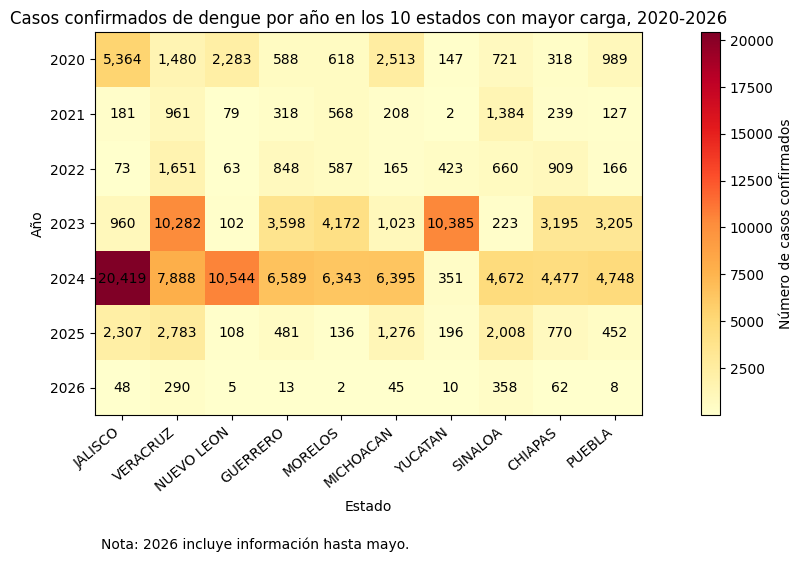

In [101]:
# mapa de calor estado-año

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(casos_estado_anio.values, cmap='YlOrRd')

ax.set_title("Casos confirmados de dengue por año en los 10 estados con mayor carga, 2020-2026")
ax.set_xlabel("Estado")
ax.set_ylabel("Año")

ax.set_xticks(range(len(casos_estado_anio.columns)))
ax.set_xticklabels(casos_estado_anio.columns, rotation=40, ha="right")

ax.set_yticks(range(len(casos_estado_anio.index)))
ax.set_yticklabels(casos_estado_anio.index)

# Anotar valores
for i in range(casos_estado_anio.shape[0]):
    for j in range(casos_estado_anio.shape[1]):
        valor = casos_estado_anio.iloc[i, j]
        ax.text(
            j,
            i,
            f"{int(valor):,}",
            ha="center",
            va="center",
            fontsize=10
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Número de casos confirmados")

ax.text(
    0.01,
    -0.35,
    "Nota: 2026 incluye información hasta mayo.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "fig_15_heatmap_top10_estados_anio_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

In [47]:
# Concentración municipal de casos confirmados


# usamos casos_municipio_df 
pareto_municipios = casos_municipio_df.copy()

pareto_municipios = pareto_municipios.sort_values(
    "CASOS_CONFIRMADOS",
    ascending=False
).reset_index(drop=True)

pareto_municipios["RANK"] = pareto_municipios.index + 1

pareto_municipios["CASOS_ACUMULADOS"] = (
    pareto_municipios["CASOS_CONFIRMADOS"].cumsum()
)

pareto_municipios["PORCENTAJE_ACUMULADO"] = (
    100 * pareto_municipios["CASOS_ACUMULADOS"]
    / pareto_municipios["CASOS_CONFIRMADOS"].sum()
)

# Municipios necesarios para alcanzar ciertos umbrales
umbrales = [50, 75, 90]

resumen_concentracion = []

for u in umbrales:
    n_mun = pareto_municipios.loc[
        pareto_municipios["PORCENTAJE_ACUMULADO"] >= u,
        "RANK"
    ].iloc[0]
    
    resumen_concentracion.append({
        "UMBRAL_PORCENTAJE": u,
        "MUNICIPIOS_NECESARIOS": int(n_mun),
        "TOTAL_MUNICIPIOS": len(pareto_municipios),
        "PORCENTAJE_MUNICIPIOS": 100 * n_mun / len(pareto_municipios)
    })

resumen_concentracion_df = pd.DataFrame(resumen_concentracion)

print("Resumen de concentración municipal:")
display(resumen_concentracion_df)

print("\nTop 20 municipios con porcentaje acumulado:")
display(
    pareto_municipios[
        [
            "RANK",
            "ESTADO",
            "MUNICIPIO",
            "CASOS_CONFIRMADOS",
            "PORCENTAJE",
            "PORCENTAJE_ACUMULADO"
        ]
    ].head(20)
)

Resumen de concentración municipal:


,UMBRAL_PORCENTAJE,MUNICIPIOS_NECESARIOS,TOTAL_MUNICIPIOS,PORCENTAJE_MUNICIPIOS
0,50,62,1746,3.550974
1,75,199,1746,11.397480
2,90,462,1746,26.460481



Top 20 municipios con porcentaje acumulado:


,RANK,ESTADO,MUNICIPIO,CASOS_CONFIRMADOS,PORCENTAJE,PORCENTAJE_ACUMULADO
0,1,JALISCO,GUADALAJARA,7469,3.073675,3.073675
1,2,YUCATAN,MERIDA,5055,2.080255,5.153931
2,3,GUERRERO,ACAPULCO DE JUAREZ,4367,1.797127,6.951057
3,4,JALISCO,ZAPOPAN,4185,1.722229,8.673287
4,5,VERACRUZ,VERACRUZ,4152,1.708649,10.381936
5,6,QUINTANA ROO,BENITO JUAREZ,3806,1.566262,11.948197
6,7,NUEVO LEON,MONTERREY,3690,1.518525,13.466722
7,8,JALISCO,SAN PEDRO TLAQUEPAQUE,3615,1.487660,14.954383
8,9,AGUASCALIENTES,AGUASCALIENTES,3494,1.437866,16.392249
9,10,TABASCO,CENTRO,3347,1.377372,17.769620


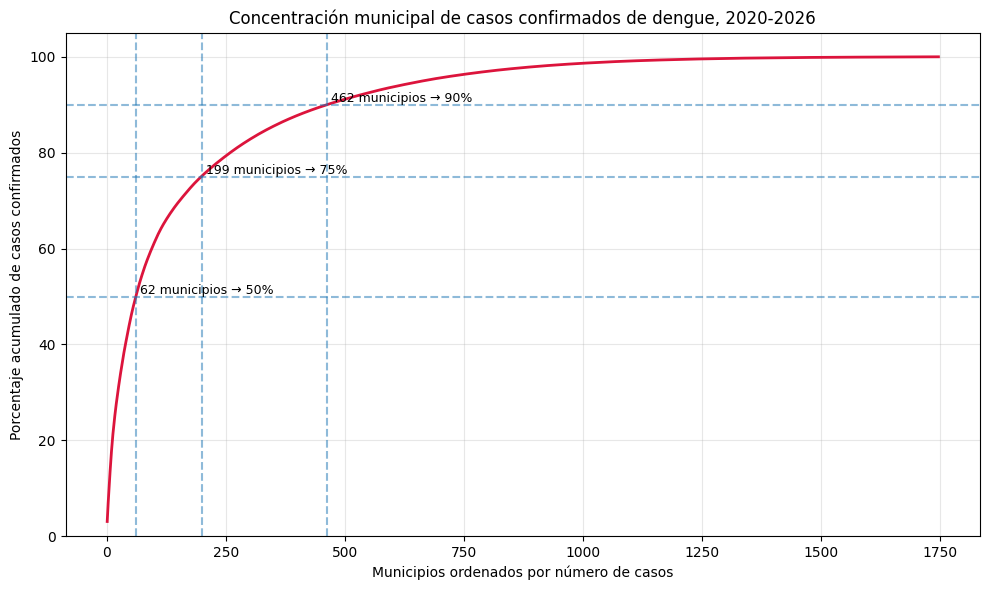

In [48]:
# Curva de concentración municipal

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    pareto_municipios["RANK"],
    pareto_municipios["PORCENTAJE_ACUMULADO"],
    linewidth=2, color='crimson'
)

for u in umbrales:
    n_mun = pareto_municipios.loc[
        pareto_municipios["PORCENTAJE_ACUMULADO"] >= u,
        "RANK"
    ].iloc[0]
    
    ax.axhline(u, linestyle="--", alpha=0.5)
    ax.axvline(n_mun, linestyle="--", alpha=0.5)
    
    ax.text(
        n_mun,
        u,
        f" {int(n_mun)} municipios → {u}%",
        va="bottom",
        fontsize=9
    )

ax.set_title("Concentración municipal de casos confirmados de dengue, 2020-2026")
ax.set_xlabel("Municipios ordenados por número de casos")
ax.set_ylabel("Porcentaje acumulado de casos confirmados")

ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_16_concentracion_municipal_casos_confirmados_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()



In [49]:
# Guardar tablas resumen del EDA

TABLE_DIR = BASE / "tablas_eda"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Guardar tablas principales
casos_anuales_df.to_csv(
    TABLE_DIR / "tabla_01_casos_confirmados_anuales.csv",
    index=False,
    encoding="utf-8"
)

casos_mensuales_df.to_csv(
    TABLE_DIR / "tabla_02_casos_confirmados_mensuales.csv",
    index=False,
    encoding="utf-8"
)

tabla_mensual.to_csv(
    TABLE_DIR / "tabla_03_estacionalidad_mensual_por_anio.csv",
    encoding="utf-8"
)

casos_estado_df.to_csv(
    TABLE_DIR / "tabla_04_casos_confirmados_por_estado.csv",
    index=False,
    encoding="utf-8"
)

casos_region_df.to_csv(
    TABLE_DIR / "tabla_05_casos_confirmados_por_region.csv",
    index=False,
    encoding="utf-8"
)

casos_region_anio.to_csv(
    TABLE_DIR / "tabla_06_casos_confirmados_region_anio.csv",
    encoding="utf-8"
)

casos_region_anio_pct.to_csv(
    TABLE_DIR / "tabla_07_porcentaje_region_anio.csv",
    encoding="utf-8"
)

casos_sexo_df.to_csv(
    TABLE_DIR / "tabla_08_casos_confirmados_por_sexo.csv",
    index=False,
    encoding="utf-8"
)

casos_grupo_edad_df.to_csv(
    TABLE_DIR / "tabla_09_casos_confirmados_por_grupo_edad.csv",
    index=False,
    encoding="utf-8"
)

grupo_edad_sexo.to_csv(
    TABLE_DIR / "tabla_10_casos_confirmados_grupo_edad_sexo.csv",
    encoding="utf-8"
)

grupo_edad_sexo_pct.to_csv(
    TABLE_DIR / "tabla_11_porcentaje_grupo_edad_sexo.csv",
    encoding="utf-8"
)

casos_municipio_df.to_csv(
    TABLE_DIR / "tabla_12_casos_confirmados_por_municipio.csv",
    index=False,
    encoding="utf-8"
)

pareto_municipios.to_csv(
    TABLE_DIR / "tabla_13_pareto_municipal.csv",
    index=False,
    encoding="utf-8"
)

resumen_concentracion_df.to_csv(
    TABLE_DIR / "tabla_14_resumen_concentracion_municipal.csv",
    index=False,
    encoding="utf-8"
)
